In [2]:
# Import or install Sionna
try:
    import sionna.rt
except ImportError as e:
    import os
    os.system("pip install sionna-rt")
    import sionna.rt

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import drjit as dr
import mitsuba as mi

no_preview = False # Toggle to False to use the preview widget


%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
    
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, ITURadioMaterial,\
    Camera, PathSolver, InteractionType, RadioMapSolver
from sionna.rt.utils import r_hat

장면 로딩 및 객체 병합

In [3]:
from sionna.rt.scene import load_scene

scene = load_scene("/data1/mh/sionna/src/sionna/rt/scenes/kookmin/kookmin_itu.xml")
#cam = Camera(position=[0, 600, -2000], look_at=[0, 0, 0])
cam = Camera(position=[0, 200, -1000], look_at=[0, 0, 0])
if no_preview:
    scene.render(camera=cam);
else:
    scene.preview();


In [4]:
for name, obj in scene.objects.items():
    print(f'{name:<15}{obj.radio_material.name}')

elm__23        wall
elm__24        roof
elm__25        8b4513
elm__26        2f4f4f
elm__27        red
elm__28        white
elm__29        gray
elm__30        black
elm__31        darkgrey
elm__32        grey
elm__33        lightgrey
elm__34        silver
elm__35        brown
elm__36        d2aa6d
elm__37        a58e9a
elm__38        ffe0a0
elm__39        dda088
elm__40        f4a460
elm__41        green
elm__42        696969
elm__43        f4e1c3
elm__44        5a564b
elm__89        itu_concrete
elm__00        roads_primary
elm__54        forest
elm__52        areas_pedestrian
elm__50        water
elm__48        vegetation
elm__46        areas_railways


In [5]:
import mitsuba as mi
import drjit as dr
from sionna.rt import load_scene, Camera
from sionna.rt import ITURadioMaterial

# 1. 장면 로드
scene = load_scene("/data1/mh/sionna/src/sionna/rt/scenes/kookmin/kookmin_itu.xml")

target_id = "elm__00"

if target_id in scene.objects:
    # [수정] thickness 매개변수 추가 (예: 0.2 미터)
    red_road_mat = ITURadioMaterial(name="red_road_mat",
                                    itu_type="concrete",
                                    thickness=2,  # <--- 이 부분을 추가하세요
                                    color=[1.0, 0.0, 0.0]) 
    
    # 3. 씬에 재질 등록
    scene.add(red_road_mat)
    
    # 4. 도로 객체에 새 재질 할당
    scene.objects[target_id].radio_material = "red_road_mat"
    
    print(f"[성공] '{target_id}'에 빨간색 재질(두께 0.2m)을 적용했습니다.")
else:
    print(f"[실패] '{target_id}' 객체를 찾을 수 없습니다.")

# 5. 시각화
cam = Camera(position=[0, 200, 1000], look_at=[0, 0, 0])

try:
    if 'no_preview' in globals() and no_preview:
        print("Preview skipped.")
    else:
        scene.preview()
except:
    scene.preview()

[성공] 'elm__00'에 빨간색 재질(두께 0.2m)을 적용했습니다.


'elm__00' (도로) 객체에서 좌표 추출

In [6]:
road_object_id = "elm__00"
road_positions = []

print(f"[탐색] Mitsuba Scene 내부에서 '{road_object_id}' 형상을 찾습니다...")

if hasattr(scene, 'mi_scene'):
    mi_scene = scene.mi_scene
    
    # 1. Mitsuba Scene의 모든 Shape를 순회하며 ID 매칭
    target_shape = None
    for s in mi_scene.shapes():
        if s.id() == road_object_id:
            target_shape = s
            break
    
    if target_shape: 
        try:           
            params = mi.traverse(target_shape)
                        
            if 'vertex_positions' in params:
                vertex_buffer = params['vertex_positions']
                
                # NumPy 변환 (1차원 배열: x, y, z, x, y, z ...)
                vertices_flat = np.array(vertex_buffer)
                
                # (N, 3) 형태로 변환 (x, y, z)
                if len(vertices_flat) > 0:
                    vertices = vertices_flat.reshape(-1, 3)
                    road_positions = vertices
                    print(f"  -> 추출된 도로 좌표 수: {len(road_positions)}개")
                else:
                    print("  [경고] 버퍼가 비어있습니다.")
            else:
                print(f"[오류] '{road_object_id}' 객체에 'vertex_positions' 속성이 없습니다.")

        except Exception as e:
            print(f"[오류] Vertex 추출 중 에러 발생: {e}")
    else:
        print(f"[실패] ID가 '{road_object_id}'인 Shape를 mi_scene에서 찾을 수 없습니다.")
else:
    print("[오류] scene 객체에서 'mi_scene' 속성을 찾을 수 없습니다.")

[탐색] Mitsuba Scene 내부에서 'elm__00' 형상을 찾습니다...
  -> 추출된 도로 좌표 수: 610개


V2X 차량 배치 (송신기 1대, 나머지 수신기)

In [7]:
if len(road_positions) > 0:
    # (1) 안테나 스펙 정의 (모든 차량 공통)
    # V2X용 단일 안테나 (1x1), 등방성 패턴(iso), 수직 편파(V)
    # 송신기용 안테나
    scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")
    # 수신기용 안테나 (송신기와 동일하게 설정)
    scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")

    # (2) 차량 위치 , 크기 선정
    num_cars = 20       #차량 대수
    vis_radius = 10.0    #차량 크기
    
    # 좌표가 부족할 경우를 대비한 안전장치
    if len(road_positions) < num_cars:
        print("좌표가 부족하여 중복을 허용합니다.")
        selected_indices = np.random.choice(len(road_positions), num_cars, replace=True)
    else:
        selected_indices = np.random.choice(len(road_positions), num_cars, replace=False)
        
    car_positions = road_positions[selected_indices]

    print(f"\n[V2X 배치] 총 {num_cars}대의 차량을 배치합니다.")
    print("  - 차량 1 (Index 0): 송신 차량 (Tx)")
    print(f"  - 차량 2~{num_cars}: 수신 차량 (Rx)")

# (3) 송신기/수신기 배치 루프
    for i, pos in enumerate(car_positions):
        # [수정] NumPy float32 -> Python float 변환
        # pos가 numpy array라면 pos[0], pos[1]은 numpy scalar입니다.
        # 이를 float()로 감싸주거나 .item()을 호출해야 합니다.
        
        x_val = float(pos[0])
        y_val = float(pos[1])
        z_val = float(pos[2]) + 1.5
        
        ant_pos = [x_val, y_val, z_val]
        
        # 첫 번째 차량(i=0)은 송신기(Tx)로 설정
        if i <= 2:
            tx_name = "Car_Tx_Source"
            if tx_name in scene.transmitters: scene.remove(tx_name)
            
            # 송신기 추가
            #tx = Transmitter(name=tx_name, position=ant_pos, orientation=[0,0,0])
            tx = Transmitter(name=tx_name, 
                             position=ant_pos, 
                             orientation=[0,0,0],
                             color=[0.0, 0.0, 1.0],
                             display_radius=vis_radius) 
            scene.add(tx)
            print(f"  [Tx] 차량 배치 완료: {ant_pos}")

        # 나머지 차량(i > 0)은 수신기(Rx)로 설정
        else:
            rx_name = f"Car_Rx_{i}"
            if rx_name in scene.receivers: scene.remove(rx_name)
            
            # 수신기 추가
            rx = Receiver(name=rx_name,
                        position=ant_pos, 
                        orientation=[0,0,0],
                        display_radius=vis_radius)
            scene.add(rx)
            # print(f"  [Rx] 차량 {i} 배치 완료")




[V2X 배치] 총 20대의 차량을 배치합니다.
  - 차량 1 (Index 0): 송신 차량 (Tx)
  - 차량 2~20: 수신 차량 (Rx)
  [Tx] 차량 배치 완료: [-125.84249114990234, 1.2859340803024304e-14, -208.5089569091797]
  [Tx] 차량 배치 완료: [-243.563232421875, 1.7607714331707713e-14, -286.0557861328125]
  [Tx] 차량 배치 완료: [298.4385986328125, 1.7450379655821122e-14, -283.486328125]


In [1]:
#카메라 설정
cam = Camera(position=[0, 200, 1000], look_at=[0, 0, 0])

# 들여쓰기 수정 (try를 맨 앞으로 당김)

try:
    if 'no_preview' in globals() and no_preview:
        print("Preview skipped.")
    else:
        scene.preview()
except:
    scene.preview()



NameError: name 'Camera' is not defined


import mitsuba as mi
import drjit as dr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray, Camera
from matplotlib.animation import ArtistAnimation
# =========================================================
# 1. 초기 설정 (장면 및 도로 좌표 로드)
# =========================================================

scene = load_scene("/data1/mh/sionna/src/sionna/rt/scenes/kookmin/kookmin_itu.xml")

# 도로 객체('elm__00')에서 좌표 추출 (이전 로직 활용)
def get_road_vertices(scene, obj_id="elm__00"):
    if hasattr(scene, 'mi_scene'):
        for s in scene.mi_scene.shapes():
            if s.id() == obj_id:
                params = mi.traverse(s)
                if 'vertex_positions' in params:
                    flat = np.array(params['vertex_positions'])
                    return flat.reshape(-1, 3)
    return np.array([])

road_positions = get_road_vertices(scene)

if len(road_positions) == 0:
    raise ValueError("도로 좌표를 찾을 수 없습니다.")

# =========================================================
# 2. 차량(Rx, Tx) 초기화 클래스 정의
# =========================================================
class Vehicle:
    def __init__(self, name, role, road_points, speed_kmh):
        self.name = name
        self.role = role # 'tx' or 'rx'
        self.road_points = road_points
        self.speed_mps = speed_kmh * (1000 / 3600) # km/h -> m/s 변환
        
        # 초기 위치 및 목표 위치 설정
        self.current_idx = np.random.choice(len(road_points))
        self.target_idx = np.random.choice(len(road_points))
        
        self.pos = self.road_points[self.current_idx].copy()
        self.pos[2] += 1.5 # 높이 보정
        self.update_target()

    def update_target(self):
        """새로운 목표 지점 설정 (단순 랜덤)"""
        self.target_idx = np.random.choice(len(self.road_points))
        self.target_pos = self.road_points[self.target_idx].copy()
        self.target_pos[2] += 1.5
        
        # 방향 벡터 계산 (Unit Vector)
        direction = self.target_pos - self.pos
        distance = np.linalg.norm(direction)
        
        if distance > 0:
            self.direction = direction / distance
        else:
            self.direction = np.zeros(3)
            self.update_target() # 제자리라면 다시 뽑기

    def move(self, dt):
        """시간 dt(초) 만큼 이동"""
        # 이동 거리 = 속도 * 시간
        step_distance = self.speed_mps * dt
        
        # 목표까지 남은 거리
        dist_to_target = np.linalg.norm(self.target_pos - self.pos)
        
        if step_distance >= dist_to_target:
            # 목표 도달 시: 위치를 목표로 옮기고 새로운 목표 설정
            self.pos = self.target_pos
            self.update_target()
        else:
            # 목표를 향해 이동
            self.pos += self.direction * step_distance
            
    def update_scene(self, scene):
        """Sionna 씬에 위치 반영"""
        # 기존 객체 제거 후 재배치 (가장 안전한 방법)
        if self.role == 'tx':
            if self.name in scene.transmitters:
                scene.remove(self.name)
            # Tx: 빨간색
            obj = Transmitter(name=self.name, position=self.pos, orientation=[0,0,0], color=[1.0, 0.0, 0.0])
            scene.add(obj)
            
        elif self.role == 'rx':
            if self.name in scene.receivers:
                scene.remove(self.name)
            # Rx: 파란색 (요청사항 반영)
            obj = Receiver(name=self.name, position=self.pos, orientation=[0,0,0], color=[0.0, 0.0, 1.0])
            scene.add(obj)

# =========================================================
# 3. 차량 생성 및 시뮬레이션 설정
# =========================================================
# 안테나 설정
scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")
scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")

# 차량 리스트 생성
vehicles = []
num_total_cars = 20
num_tx = 2

# 속도 설정 (여기서 속도를 조절하세요!)
SPEED_TX = 30.0  # Tx 속도 (km/h)
SPEED_RX = 60.0  # Rx 속도 (km/h) - 파란색 차를 더 빠르게

print("차량 생성 중...")
for i in range(num_total_cars):
    if i < num_tx:
        # Tx (빨강)
        v = Vehicle(f"Car_Tx_{i}", 'tx', road_positions, SPEED_TX)
    else:
        # Rx (파랑)
        v = Vehicle(f"Car_Rx_{i}", 'rx', road_positions, SPEED_RX)
    
    vehicles.append(v)
    v.update_scene(scene) # 초기 배치

# =========================================================
# 4. 애니메이션 생성 (GIF 저장)
# =========================================================
print("애니메이션 렌더링 시작... (시간이 소요됩니다)")

# 카메라 설정 (전체를 조망하는 Top View)
cam = Camera(position=[0, 0, 1200], look_at=[0, 0, 0])

# 애니메이션 설정
fps = 10         # 초당 프레임 수
duration = 5.0   # 시뮬레이션 시간 (초)
total_frames = int(fps * duration)
dt = 1.0 / fps   # 프레임 간 시간 간격 (초)

fig = plt.figure(figsize=(10, 6))
plt.axis('off')

# 렌더링 된 이미지를 담을 리스트
frames = []

for frame_idx in range(total_frames):
    # 1. 모든 차량 이동
    for v in vehicles:
        v.move(dt)
        v.update_scene(scene)
    
    # 2. 렌더링 (저해상도로 빠르게)
    # return_bitmap=True를 추가하여 이미지 데이터(Tensor)를 반환받습니다.
    img = scene.render(camera=cam, num_samples=32, return_bitmap=True)
    
    # 3. 이미지 처리 및 저장
    # Dr.Jit 텐서를 Numpy로 변환 후 시각화
    img_np = np.array(img)
    # 톤매핑 (밝기 조절) - 필요시 clip
    img_np = np.clip(img_np ** (1.0/2.2), 0, 1) 
    
    im = plt.imshow(img_np, animated=True)
    frames.append([im])
    
    print(f"Frame {frame_idx+1}/{total_frames} 렌더링 완료")

# 애니메이션 저장
ani = ArtistAnimation(fig, frames, interval=1000/fps, blit=True)
ani.save("v2x_simulation.gif", writer='pillow', fps=fps)

print("\n[완료] 'v2x_simulation.gif' 파일이 저장되었습니다.")

In [9]:
# ========================================================
# [설정] 도로(elm__00) 위에서 이동 경로 자동 생성
# ========================================================

# 1. 설정 변수
num_cars = 2            # 움직일 자동차 대수
target_speed_min = 10.0 # 최소 속도 (m/s)
target_speed_max = 20.0 # 최대 속도 (m/s)

cars_config = []

# road_positions에 데이터가 있는지 확인
if len(road_positions) > 0:
    for i in range(num_cars):
        # 2. 도로 좌표 목록에서 무작위로 2개의 인덱스 뽑기 (중복 없이)
        # idx[0]: 시작점 인덱스, idx[1]: 도착점 인덱스
        indices = np.random.choice(len(road_positions), 2, replace=False)
        
        start_raw = road_positions[indices[0]] # [x, y, z] (NumPy array)
        end_raw = road_positions[indices[1]]   # [x, y, z] (NumPy array)
        
        # 3. 높이(z) 보정 (바닥 + 1.5m) 및 Python float 리스트로 변환
        # Mitsuba 호환성을 위해 float() 형변환 필수
        start_pos = [float(start_raw[0]), float(start_raw[1]), float(start_raw[2]) + 1.5]
        end_pos   = [float(end_raw[0]),   float(end_raw[1]),   float(end_raw[2]) + 1.5]
        
        # 4. 랜덤 속도 설정
        speed = np.random.uniform(target_speed_min, target_speed_max)
        
        # 5. 설정 딕셔너리 생성
        car_info = {
            "name": f"Car_Tx_{i}",
            "start": start_pos,
            "end": end_pos,
            "speed": speed
        }
        cars_config.append(car_info)
        
        print(f"[{car_info['name']}] 경로 설정 완료")
        print(f"  - 시작: {start_pos}")
        print(f"  - 도착: {end_pos}")
        print(f"  - 속도: {speed:.2f} m/s")

else:
    print("[오류] road_positions 데이터가 비어있습니다. 도로 좌표 추출을 먼저 수행해주세요.")

# ========================================================
# [초기화] 위에서 만든 cars_config를 바탕으로 객체 생성
# ========================================================
tx_objects = []

for config in cars_config:
    # 1. 방향 벡터 계산 (도착점 - 시작점)
    start_vec = np.array(config["start"])
    end_vec = np.array(config["end"])
    direction = end_vec - start_vec
    
    # 거리가 0이면 이동 안 함
    distance = np.linalg.norm(direction)
    if distance > 0:
        direction_norm = direction / distance
    else:
        direction_norm = np.zeros(3)
        
    # 2. 속도 벡터(Velocity Vector) 계산
    velocity_vec = direction_norm * config["speed"]
    
    # 3. 송신기(자동차) 생성
    # 앞서 만든 로직대로 시작점(start_pos)에 배치
    tx = Transmitter(name=config["name"],
                     position=config["start"], # 여기 들어가는 값이 도로 위 좌표임
                     orientation=[0,0,0],
                     velocity=velocity_vec,
                     color=[0.0, 0.0, 1.0]) # 파란색
    
    # 기존에 같은 이름이 있다면 제거 후 추가
    if config["name"] in scene.transmitters:
        scene.remove(config["name"])
        
    scene.add(tx)
    
    # 시뮬레이션용 데이터 저장
    tx_objects.append({
        "tx": tx,
        "current_pos": start_vec,
        "velocity": velocity_vec,
        "end_pos": end_vec,
        "finished": False
    })

[Car_Tx_0] 경로 설정 완료
  - 시작: [-238.36106872558594, 2.395643125335193e-14, -389.7381896972656]
  - 도착: [-237.54440307617188, 2.757218959441657e-14, -448.7879943847656]
  - 속도: 19.42 m/s
[Car_Tx_1] 경로 설정 완료
  - 시작: [-251.05885314941406, 7.52166104194766e-15, -121.33804321289062]
  - 도착: [316.8099670410156, 1.5479962486007227e-14, -251.3069610595703]
  - 속도: 18.38 m/s


In [10]:
import plotly.graph_objects as go
import numpy as np

# 1. 데이터 준비
x = road_positions[:, 0]
y = road_positions[:, 1]
indices = list(range(len(road_positions)))

# 2. 인터랙티브 지도 생성
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=x, y=y,
    mode='markers',
    marker=dict(size=5, color='blue'),
    text=indices,  # 마우스를 올리면 이 번호(Index)가 뜸
    hovertemplate='<b>Index: %{text}</b><br>X: %{x:.1f}<br>Y: %{y:.1f}<extra></extra>'
))

fig.update_layout(
    title="도로 점 확인용 지도 (마우스를 올려보세요)",
    width=1000, height=800,
    hovermode='closest'
)

fig.show()

일부 경로(ㅏ에서 ㅡ부분의 경로)
path_indices = [
    412, 410, 408, 406, 404, 401, 400, 72, 69, 68, 342, 340, 338, 335, 334, 
    88, 86, 84, 81, 464, 462, 459, 295, 370, 294, 368, 366, 363, 308, 306, 
    303, 302, 514, 511, 510, 488, 483, 482, 172, 269, 292, 288, 286, 284, 
    281, 604, 601, 507, 289, 506, 268, 522, 517, 516, 122, 120, 117, 116, 
    525, 582
]

In [11]:
import numpy as np
import mitsuba as mi
from sionna.rt import Transmitter, PlanarArray, load_scene, Camera
import os
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 0. 사전 준비 (기존 데이터 확인)
# ---------------------------------------------------------
# road_positions 변수와 scene 변수가 메모리에 로드되어 있어야 합니다.
if 'road_positions' not in globals() or len(road_positions) == 0:
    print("[Error] 'road_positions' 데이터가 없습니다. 도로 좌표 추출 코드를 먼저 실행해주세요.")
    # 실행을 중단하려면 여기서 raise SystemExit 등을 사용할 수 있습니다.

# ---------------------------------------------------------
# 1. 경로 및 시뮬레이션 환경 설정
# ---------------------------------------------------------

# 기존에 배치된 모든 차량(송신기) 제거 (차량 1대만 남기기 위함)
if hasattr(scene, 'transmitters'):
    for tx_name in list(scene.transmitters.keys()):
        scene.remove(tx_name)
    print("[Info] 기존 차량을 모두 제거했습니다.")

# 경로 인덱스
path_indices = [
    412, 410, 408, 406, 404, 401, 400, 72, 69, 68, 342, 340, 338, 335, 334, 
    88, 86, 84, 81, 464, 462, 459, 295, 370, 294, 368, 366, 363, 308, 306, 
    303, 302, 514, 511, 510, 488, 483, 482, 172, 269, 292, 288, 286, 284, 
    281, 604, 601, 507, 289, 506, 268, 522, 517, 516, 122, 120, 117, 116, 
    525, 582
]

# 경로 좌표 추출 및 높이 보정
waypoints = road_positions[path_indices]
waypoints[:, 2] += 1.5 

# 누적 거리 계산 (보간법 사용을 위함)
diffs = waypoints[1:] - waypoints[:-1]
segment_dists = np.linalg.norm(diffs, axis=1)
cumulative_dists = np.concatenate(([0], np.cumsum(segment_dists)))
total_distance = cumulative_dists[-1]

print(f"[Simulation Info]")
print(f"  - Total Distance: {total_distance:.2f} m")

# 속도 설정 (60 km/h)
speed_kmh = 60.0
speed_ms = speed_kmh * 1000 / 3600 
total_time = total_distance / speed_ms

print(f"  - Speed: {speed_kmh} km/h ({speed_ms:.2f} m/s)")
print(f"  - Total Time: {total_time:.2f} s")

# ---------------------------------------------------------
# 2. 이동 로직 함수
# ---------------------------------------------------------
def get_location_at_distance(dist):
    dist = np.clip(dist, 0, total_distance)
    
    # 현재 거리가 속한 구간(Index) 찾기
    idx = np.searchsorted(cumulative_dists, dist) - 1
    idx = max(0, min(idx, len(waypoints) - 2))
    
    seg_start_dist = cumulative_dists[idx]
    seg_length = segment_dists[idx]
    
    if seg_length == 0:
        return waypoints[idx], np.zeros(3)

    # 선형 보간 (Linear Interpolation)
    ratio = (dist - seg_start_dist) / seg_length
    current_pos = waypoints[idx] + ratio * (waypoints[idx+1] - waypoints[idx])
    
    # 방향 벡터 계산 (속도 벡터용)
    direction = (waypoints[idx+1] - waypoints[idx]) / seg_length
    velocity = direction * speed_ms
    
    return current_pos, velocity

# ---------------------------------------------------------
# 3. 송신기 배치 및 카메라 설정 (수정됨)
# ---------------------------------------------------------

# 파란색 자동차(송신기) 1대 초기화
tx_name = "Blue_Car_Tx"
start_pos = waypoints[0].tolist()

# 안테나 패턴 설정 (없을 경우 대비)
scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")

tx = Transmitter(name=tx_name, 
                 position=start_pos, 
                 orientation=[0,0,0],
                 color=[0.0, 0.0, 1.0]) # 파란색 설정
scene.add(tx)
print(f"[Info] 차량 배치 완료: {tx_name}")

# 결과 저장 폴더 생성
output_dir = "sim_frames"
os.makedirs(output_dir, exist_ok=True)

# [핵심 수정] 카메라 설정: Z축을 반대편(-1000)으로 뒤집음
# 기존: [0, 200, 1000] -> 수정: [0, 200, -1000]
# look_at은 [0, 0, 0]을 유지하여 원점을 바라보게 함
cam = Camera(position=[0, 200, -1000], look_at=[0, 0, 0]) 

# ---------------------------------------------------------
# 4. 시뮬레이션 루프
# ---------------------------------------------------------
delta_t = 0.5  # 0.5초 단위
current_time = 0.0
frame_idx = 0

print("\n[Starting Simulation... Saving frames]")

while current_time <= total_time:
    # 1. 위치 계산 및 업데이트
    current_dist = speed_ms * current_time
    pos, vel = get_location_at_distance(current_dist)
    
    # Sionna 객체 위치 업데이트
    tx.position = pos.tolist()
    tx.velocity = vel.tolist()

    # 2. 렌더링 및 이미지 저장
    try:
        # 해상도 조절 (필요시 resolution=[1280, 720] 등으로 변경 가능)
        fig = scene.render(camera=cam, num_samples=64, resolution=[640, 480])
        
        if fig:
            ax = fig.gca()
            ax.set_title(f"Time: {current_time:.2f}s | Dist: {current_dist:.1f}m")
            
            filename = os.path.join(output_dir, f"frame_{frame_idx:04d}.png")
            fig.savefig(filename, bbox_inches='tight')
            plt.close(fig) # 메모리 해제
            
            print(f"  Saved frame {frame_idx}: T={current_time:.1f}s")
        else:
            print(f"  [Warning] Frame {frame_idx} render failed.")

    except Exception as e:
        print(f"  [Error] Failed to render frame {frame_idx}: {e}")
    
    current_time += delta_t
    frame_idx += 1

print(f"\n[Done] All frames saved in '{output_dir}' folder.")

[Info] 기존 차량을 모두 제거했습니다.
[Simulation Info]
  - Total Distance: 1200.79 m
  - Speed: 60.0 km/h (16.67 m/s)
  - Total Time: 72.05 s
[Info] 차량 배치 완료: Blue_Car_Tx

[Starting Simulation... Saving frames]
  Saved frame 0: T=0.0s
  Saved frame 1: T=0.5s
  Saved frame 2: T=1.0s
  Saved frame 3: T=1.5s
  Saved frame 4: T=2.0s
  Saved frame 5: T=2.5s
  Saved frame 6: T=3.0s
  Saved frame 7: T=3.5s
  Saved frame 8: T=4.0s
  Saved frame 9: T=4.5s
  Saved frame 10: T=5.0s
  Saved frame 11: T=5.5s
  Saved frame 12: T=6.0s
  Saved frame 13: T=6.5s
  Saved frame 14: T=7.0s
  Saved frame 15: T=7.5s
  Saved frame 16: T=8.0s
  Saved frame 17: T=8.5s
  Saved frame 18: T=9.0s
  Saved frame 19: T=9.5s
  Saved frame 20: T=10.0s
  Saved frame 21: T=10.5s
  Saved frame 22: T=11.0s
  Saved frame 23: T=11.5s
  Saved frame 24: T=12.0s
  Saved frame 25: T=12.5s
  Saved frame 26: T=13.0s
  Saved frame 27: T=13.5s
  Saved frame 28: T=14.0s
  Saved frame 29: T=14.5s
  Saved frame 30: T=15.0s
  Saved frame 31: T=15.5s

/home/lab602/miniconda3/envs/sionna_env/lib/python3.11/site-packages/drjit/ast.py:838: RuntimeWarning:

The AST-transforming decorator @drjit.syntax was called more than 1000 times by your program. Since transforming and recompiling Python code is a relatively expensive operation, it should not be used within loops or subroutines. Please move the function to be transformed to the top program level and decorate it there.



  Saved frame 54: T=27.0s
  Saved frame 55: T=27.5s
  Saved frame 56: T=28.0s
  Saved frame 57: T=28.5s
  Saved frame 58: T=29.0s
  Saved frame 59: T=29.5s
  Saved frame 60: T=30.0s
  Saved frame 61: T=30.5s
  Saved frame 62: T=31.0s
  Saved frame 63: T=31.5s
  Saved frame 64: T=32.0s
  Saved frame 65: T=32.5s
  Saved frame 66: T=33.0s
  Saved frame 67: T=33.5s
  Saved frame 68: T=34.0s
  Saved frame 69: T=34.5s
  Saved frame 70: T=35.0s
  Saved frame 71: T=35.5s
  Saved frame 72: T=36.0s
  Saved frame 73: T=36.5s
  Saved frame 74: T=37.0s
  Saved frame 75: T=37.5s
  Saved frame 76: T=38.0s
  Saved frame 77: T=38.5s
  Saved frame 78: T=39.0s
  Saved frame 79: T=39.5s
  Saved frame 80: T=40.0s
  Saved frame 81: T=40.5s
  Saved frame 82: T=41.0s
  Saved frame 83: T=41.5s
  Saved frame 84: T=42.0s
  Saved frame 85: T=42.5s
  Saved frame 86: T=43.0s
  Saved frame 87: T=43.5s
  Saved frame 88: T=44.0s
  Saved frame 89: T=44.5s
  Saved frame 90: T=45.0s
  Saved frame 91: T=45.5s
  Saved fram

[Simulation Info]
  - Total Dist: 1200.79 m
  - Total Time: 72.05 s

[Info] 기지국 4개 배치 중...
  -> BaseStation_0: [448.2762  30.      25.    ]
  -> BaseStation_1: [300.89908  30.       25.     ]
  -> BaseStation_2: [-128.50803   30.        25.     ]
  -> BaseStation_3: [-191.64143   30.        25.     ]

[Start Channel Sounding...]
  T=  0.0s | Dist=   0.0m | Best RSRP=-63.81 dBm (BS_0)
  T=  0.5s | Dist=   8.3m | Best RSRP=-63.68 dBm (BS_0)
  T=  1.0s | Dist=  16.7m | Best RSRP=-63.55 dBm (BS_0)
  T=  1.5s | Dist=  25.0m | Best RSRP=-63.42 dBm (BS_0)
  T=  2.0s | Dist=  33.3m | Best RSRP=-63.31 dBm (BS_0)
  T=  2.5s | Dist=  41.7m | Best RSRP=-68.88 dBm (BS_4)
  T=  3.0s | Dist=  50.0m | Best RSRP=-68.76 dBm (BS_6)
  T=  3.5s | Dist=  58.3m | Best RSRP=-68.64 dBm (BS_6)
  T=  4.0s | Dist=  66.7m | Best RSRP=-69.31 dBm (BS_6)
  T=  4.5s | Dist=  75.0m | Best RSRP=-69.20 dBm (BS_6)
  T=  5.0s | Dist=  83.3m | Best RSRP=-69.08 dBm (BS_3)
  T=  5.5s | Dist=  91.7m | Best RSRP=-68.96 dBm (BS_

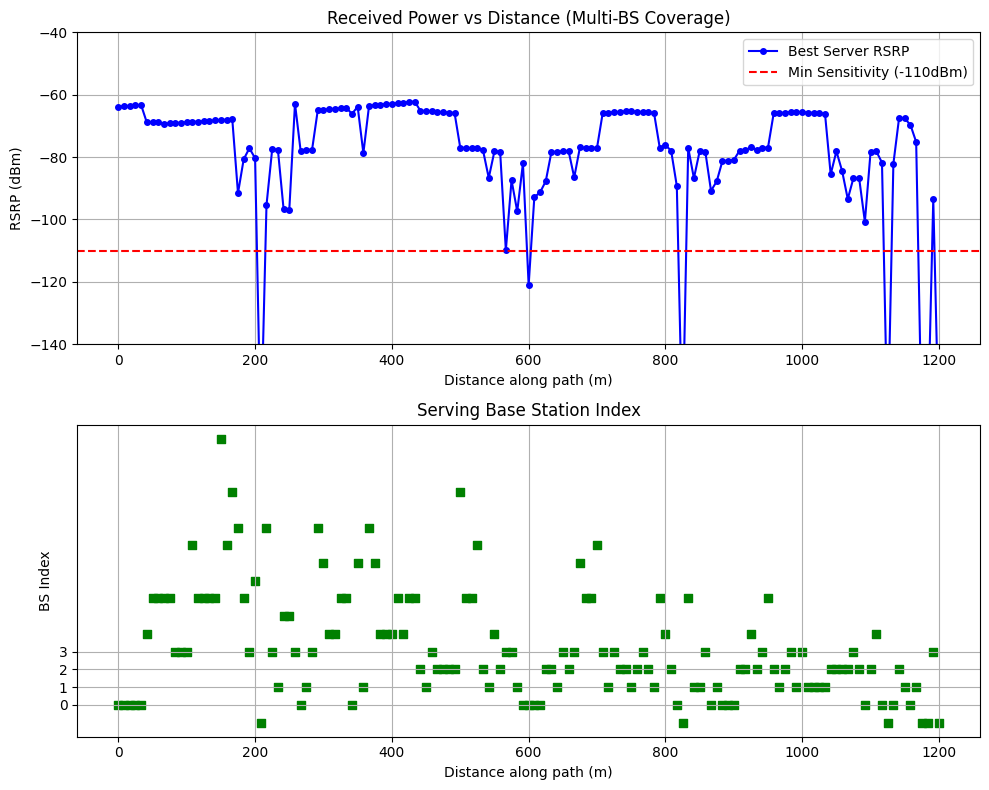

[Saved] 'result_multi_bs_sounding.png'


In [ ]:
import numpy as np
import mitsuba as mi
import matplotlib.pyplot as plt
import os
import drjit as dr
from sionna.rt import Transmitter, Receiver, PlanarArray, load_scene, Camera, PathSolver

# ---------------------------------------------------------
# 0. 데이터 및 환경 초기화
# ---------------------------------------------------------
xml_path = "/data1/mh/sionna/src/sionna/rt/scenes/kookmin/kookmin_itu.xml"
scene = load_scene(xml_path)

if 'road_positions' not in globals() or len(road_positions) == 0:
    raise ValueError("[Error] 'road_positions' 데이터가 없습니다. 좌표 추출 코드를 먼저 실행하세요.")

# 객체 초기화
if hasattr(scene, 'transmitters'):
    for k in list(scene.transmitters.keys()): scene.remove(k)
if hasattr(scene, 'receivers'):
    for k in list(scene.receivers.keys()): scene.remove(k)

# ---------------------------------------------------------
# 1. 이동 경로 및 속도 설정 (기존과 동일)
# ---------------------------------------------------------
path_indices = [
    412, 410, 408, 406, 404, 401, 400, 72, 69, 68, 342, 340, 338, 335, 334, 
    88, 86, 84, 81, 464, 462, 459, 295, 370, 294, 368, 366, 363, 308, 306, 
    303, 302, 514, 511, 510, 488, 483, 482, 172, 269, 292, 288, 286, 284, 
    281, 604, 601, 507, 289, 506, 268, 522, 517, 516, 122, 120, 117, 116, 
    525, 582
]

max_valid_idx = len(road_positions) - 1
valid_path = [i for i in path_indices if i <= max_valid_idx]
waypoints = road_positions[valid_path]
waypoints[:, 2] += 1.5 

diffs = waypoints[1:] - waypoints[:-1]
segment_dists = np.linalg.norm(diffs, axis=1)
cumulative_dists = np.concatenate(([0], np.cumsum(segment_dists)))
total_distance = cumulative_dists[-1]

speed_ms = 60.0 * 1000 / 3600
total_time = total_distance / speed_ms

print(f"[Simulation Info]")
print(f"  - Total Dist: {total_distance:.2f} m")
print(f"  - Total Time: {total_time:.2f} s")

def get_location_at_distance(dist):
    dist = np.clip(dist, 0, total_distance)
    idx = np.searchsorted(cumulative_dists, dist) - 1
    idx = max(0, min(idx, len(waypoints) - 2))
    seg_start = cumulative_dists[idx]
    seg_len = segment_dists[idx]
    if seg_len == 0: return waypoints[idx], np.zeros(3)
    ratio = (dist - seg_start) / seg_len
    pos = waypoints[idx] + ratio * (waypoints[idx+1] - waypoints[idx])
    direction = (waypoints[idx+1] - waypoints[idx]) / seg_len
    vel = direction * speed_ms
    return pos, vel

# ---------------------------------------------------------
# 2. 다중 기지국(Tx 4개) 및 차량(Rx) 배치
# ---------------------------------------------------------
scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")
scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")

# [수정] 기지국 4개를 경로상에 등간격으로 배치
num_bs = 4
bs_indices = np.linspace(0, len(waypoints)-1, num_bs, dtype=int)

print(f"\n[Info] 기지국 {num_bs}개 배치 중...")
for i, idx in enumerate(bs_indices):
    pos = waypoints[idx].copy()
    # 도로변 건물 옥상 느낌으로 위치 조정
    pos[0] += 30.0  # 도로 옆 30m
    pos[1] += 30.0
    pos[2] = 25.0   # 높이 25m
    
    tx_name = f"BaseStation_{i}"
    tx = Transmitter(name=tx_name, position=pos.tolist(), orientation=[0,0,0])
    scene.add(tx)
    print(f"  -> {tx_name}: {pos}")

# 차량 배치
rx_name = "Car_Rx"
start_pos = waypoints[0].tolist()
rx = Receiver(name=rx_name, 
              position=start_pos, 
              orientation=[0,0,0], 
              color=[0.0, 0.0, 1.0]) 
scene.add(rx)

# ---------------------------------------------------------
# 3. PathSolver
# ---------------------------------------------------------
solver = PathSolver() 

# ---------------------------------------------------------
# 4. 시뮬레이션 루프
# ---------------------------------------------------------
delta_t = 0.5 
current_time = 0.0

history = {
    "time": [],
    "distance": [],
    "power_dbm": [], # Best Server RSRP
    "serving_cell": [] # 어떤 기지국에 연결되었는지
}

output_dir = "sim_frames_sounding"
os.makedirs(output_dir, exist_ok=True)
cam = Camera(position=[0, 200, -1000], look_at=[0, 0, 0])

print("\n[Start Channel Sounding...]")

frame_idx = 0
while current_time <= total_time:
    current_dist = speed_ms * current_time
    pos, vel = get_location_at_distance(current_dist)
    
    rx.position = pos.tolist()
    rx.velocity = vel.tolist()
    
    # 초기화
    best_power_dbm = -170.0
    best_bs_idx = -1
    
    try:
        paths = solver(
            scene,
            max_depth=3,
            samples_per_src=int(1e5),
            specular_reflection=True, 
            diffraction=False,
            diffuse_reflection=False
        )
        
        if paths.a is not None:
            a_np = np.array(paths.a)
            # a_np shape: [Rx(1), Tx(4), Paths(M), RxAnt(1), TxAnt(1)] 
            # -> squeeze로 불필요한 차원 제거 -> [4, M] (기지국 4개, 각 경로들)
            
            # [수정] 각 기지국별 수신 전력 계산
            # axis=-1 (경로들)에 대해 파워 합산
            # paths.a의 차원은 보통 [Target, Source, Path, ...] 순서임.
            # 여기서는 Target=1(Rx), Source=4(Tx)
            
            # [1, 4, M, 1, 1] 형태라고 가정하고 계산
            # 각 Tx(Source)별로 에너지 합산 (Non-coherent sum)
            tx_powers_linear = np.sum(np.abs(a_np)**2, axis=2) # 결과 shape: [1, 4, 1, 1]
            tx_powers_linear = tx_powers_linear.flatten()      # 결과 shape: [4]
            
            # 가장 센 신호 찾기 (Best Server Selection)
            best_bs_idx = np.argmax(tx_powers_linear)
            max_linear = tx_powers_linear[best_bs_idx]
            
            if max_linear > 1e-20:
                best_power_dbm = 10 * np.log10(max_linear) + 30
            else:
                best_power_dbm = -170.0
                best_bs_idx = -1 # No service
                
    except Exception as e:
        print(f"[Err] {e}")

    # 기록
    history["time"].append(current_time)
    history["distance"].append(current_dist)
    history["power_dbm"].append(best_power_dbm)
    history["serving_cell"].append(best_bs_idx)
    
    bs_str = f"BS_{best_bs_idx}" if best_bs_idx != -1 else "None"
    print(f"  T={current_time:5.1f}s | Dist={current_dist:6.1f}m | Best RSRP={best_power_dbm:6.2f} dBm ({bs_str})")
    
    current_time += delta_t
    frame_idx += 1

print("[Done] Simulation Finished.")

# ---------------------------------------------------------
# 5. 결과 그래프
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

# RSRP 그래프
plt.subplot(2, 1, 1)
plt.plot(history["distance"], history["power_dbm"], 'b-o', markersize=4, label='Best Server RSRP')
plt.axhline(y=-110, color='r', linestyle='--', label='Min Sensitivity (-110dBm)')
plt.title("Received Power vs Distance (Multi-BS Coverage)")
plt.xlabel("Distance along path (m)")
plt.ylabel("RSRP (dBm)")
plt.legend()
plt.grid(True)
plt.ylim(bottom=-140, top=-40)

# 연결된 기지국 ID 그래프 (Handover 확인용)
plt.subplot(2, 1, 2)
plt.scatter(history["distance"], history["serving_cell"], c='green', marker='s')
plt.title("Serving Base Station Index")
plt.xlabel("Distance along path (m)")
plt.ylabel("BS Index")
plt.yticks(range(num_bs))
plt.grid(True)

plt.tight_layout()
plt.savefig("result_multi_bs_sounding.png")
plt.show()
print("[Saved] 'result_multi_bs_sounding.png'")

Sionna 라이브러리를 사용하여 OFDM 시스템을 구성하고, 송신 신호가 Rayleigh 페이딩 채널을 통과한 후 수신단에서 LS(Least Squares) 기법으로 채널을 추정하는 과정

In [13]:
import tensorflow as tf
import numpy as np
# sionna 라이브러리가 설치되어 있어야 합니다.
try:
    import sionna
    from sionna.phy.ofdm import ResourceGrid, ResourceGridMapper, LSChannelEstimator
    from sionna.phy.channel import RayleighBlockFading, GenerateOFDMChannel, ApplyOFDMChannel
    from sionna.phy.mapping import Constellation, Mapper, BinarySource
except ImportError:
    print("Sionna 라이브러리가 설치되지 않았습니다. 'pip install sionna'를 실행해주세요.")
    exit()

# 1. 시스템 파라미터 설정
num_ofdm_symbols = 14
fft_size = 64
subcarrier_spacing = 30e3
num_tx = 1
num_streams_per_tx = 1
num_rx = 1
num_rx_ant = 1
batch_size = 64

# 2. 리소스 그리드 생성 (파일럿 패턴 포함)
# [cite_start]ResourceGrid 내에서 pilot_pattern="kronecker"를 설정하여 내부적으로 패턴을 생성하도록 합니다[cite: 4054].
rg = ResourceGrid(
    num_ofdm_symbols=num_ofdm_symbols,
    fft_size=fft_size,
    subcarrier_spacing=subcarrier_spacing,
    num_tx=num_tx,
    num_streams_per_tx=num_streams_per_tx,
    pilot_pattern="kronecker", 
    pilot_ofdm_symbol_indices=[2, 11]
)

# 3. 채널 추정기 (LS Estimator) 설정
# [cite_start]LSChannelEstimator는 수신 신호와 노이즈 분산을 입력받아 채널을 추정합니다[cite: 4147].
ls_est = LSChannelEstimator(
    resource_grid=rg,
    interpolation_type="nn"
)

# --- 시뮬레이션 흐름 ---

# (1) 데이터 생성 및 매핑
# QAM 심볼 생성
num_data_symbols = rg.num_data_symbols
# [cite_start]Constellation 객체 생성 [cite: 1531]
constellation = Constellation("qam", num_bits_per_symbol=2) # QPSK
# [cite_start]바이너리 데이터 생성 [cite: 1662]
b = BinarySource()([batch_size, num_tx, num_streams_per_tx, num_data_symbols * 2])
# [cite_start]매퍼를 통해 심볼로 변환 [cite: 1580]
mapper = Mapper(constellation=constellation)
x = mapper(b)

# [cite_start]리소스 그리드 매핑 (데이터와 파일럿을 그리드에 배치) [cite: 3816]
rg_mapper = ResourceGridMapper(rg)
x_rg = rg_mapper(x)

# (2) 채널 생성 및 적용 (OFDM Channel)
# [cite_start]Rayleigh Block Fading 채널 모델 설정 [cite: 2316]
rayleigh = RayleighBlockFading(
    num_rx=num_rx,
    num_rx_ant=num_rx_ant,
    num_tx=num_tx,
    num_tx_ant=1
)

# [cite_start]OFDM 채널 생성기 [cite: 2269]
generate_channel = GenerateOFDMChannel(
    channel_model=rayleigh,
    resource_grid=rg
)

# 채널 주파수 응답 생성 (h_freq)
h_freq = generate_channel(batch_size)

# 채널 적용 (y = h * x + n)
# [cite_start]ApplyOFDMChannel은 리스트가 아닌 개별 인자로 [x, h_freq, no]를 순서대로 받습니다[cite: 2286].
no = 0.01  # 노이즈 분산
channel_apply = ApplyOFDMChannel()

# [수정] 리스트 []를 제거하고 인자를 직접 전달
y = channel_apply(x_rg, h_freq, no) 

# (3) 채널 추정 수행
# [cite_start]LSChannelEstimator 역시 [y, no] 리스트가 아닌 y, no를 개별 인자로 받습니다[cite: 4147].
# [수정] 리스트 []를 제거하고 인자를 직접 전달
h_hat, err_var = ls_est(y, no)

# --- 결과 확인 ---
print("입력 채널 형태 (h_freq):", h_freq.shape)
print("추정 채널 형태 (h_hat):", h_hat.shape)

# 채널값 비교 (첫 번째 배치, 첫 번째 링크의 일부 데이터)
print("\n[원본 채널값 (Real part, 상위 5개)]")
print(tf.math.real(h_freq[0, 0, 0, 0, 0, 0, :5]).numpy())

print("\n[추정된 채널값 (Real part, 상위 5개)]")
print(tf.math.real(h_hat[0, 0, 0, 0, 0, 0, :5]).numpy())

# MSE(Mean Squared Error) 계산
mse = tf.reduce_mean(tf.abs(h_freq - h_hat)**2)
print(f"\nMean Squared Error (MSE): {mse:.6f}")

2025-12-15 13:21:02.958909: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765772462.969024 2867257 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765772462.971906 2867257 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765772462.980626 2867257 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765772462.980634 2867257 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765772462.980637 2867257 computation_placer.cc:177] computation placer alr

입력 채널 형태 (h_freq): (64, 1, 1, 1, 1, 14, 64)
추정 채널 형태 (h_hat): (64, 1, 1, 1, 1, 14, 64)

[원본 채널값 (Real part, 상위 5개)]
[0.35400394 0.35400394 0.35400394 0.35400394 0.35400394]

[추정된 채널값 (Real part, 상위 5개)]
[0.33343413 0.43392366 0.38552672 0.37562773 0.3783802 ]

Mean Squared Error (MSE): 0.010010


In [14]:
import numpy as np
import mitsuba as mi
import matplotlib.pyplot as plt
import os
import drjit as dr
from sionna.rt import Transmitter, Receiver, PlanarArray, load_scene, Camera, PathSolver

# ---------------------------------------------------------
# 0. 데이터 및 환경 초기화
# ---------------------------------------------------------
xml_path = "/data1/mh/sionna/src/sionna/rt/scenes/kookmin/kookmin_itu.xml"
scene = load_scene(xml_path)

if 'road_positions' not in globals() or len(road_positions) == 0:
    raise ValueError("[Error] 'road_positions' 데이터가 없습니다. 좌표 추출 코드를 먼저 실행하세요.")

# 객체 초기화
if hasattr(scene, 'transmitters'):
    for k in list(scene.transmitters.keys()): scene.remove(k)
if hasattr(scene, 'receivers'):
    for k in list(scene.receivers.keys()): scene.remove(k)

# ---------------------------------------------------------
# 1. 이동 경로 및 속도 설정
# ---------------------------------------------------------
path_indices = [
    412, 410, 408, 406, 404, 401, 400, 72, 69, 68, 342, 340, 338, 335, 334, 
    88, 86, 84, 81, 464, 462, 459, 295, 370, 294, 368, 366, 363, 308, 306, 
    303, 302, 514, 511, 510, 488, 483, 482, 172, 269, 292, 288, 286, 284, 
    281, 604, 601, 507, 289, 506, 268, 522, 517, 516, 122, 120, 117, 116, 
    525, 582
]

max_valid_idx = len(road_positions) - 1
valid_path = [i for i in path_indices if i <= max_valid_idx]
waypoints = road_positions[valid_path]
waypoints[:, 2] += 1.5 

diffs = waypoints[1:] - waypoints[:-1]
segment_dists = np.linalg.norm(diffs, axis=1)
cumulative_dists = np.concatenate(([0], np.cumsum(segment_dists)))
total_distance = cumulative_dists[-1]

speed_ms = 60.0 * 1000 / 3600
total_time = total_distance / speed_ms

print(f"[Simulation Info]")
print(f"  - Total Time: {total_time:.2f} s")

def get_location_at_distance(dist):
    dist = np.clip(dist, 0, total_distance)
    idx = np.searchsorted(cumulative_dists, dist) - 1
    idx = max(0, min(idx, len(waypoints) - 2))
    seg_start = cumulative_dists[idx]
    seg_len = segment_dists[idx]
    if seg_len == 0: return waypoints[idx], np.zeros(3)
    ratio = (dist - seg_start) / seg_len
    pos = waypoints[idx] + ratio * (waypoints[idx+1] - waypoints[idx])
    direction = (waypoints[idx+1] - waypoints[idx]) / seg_len
    vel = direction * speed_ms
    return pos, vel

# ---------------------------------------------------------
# 2. 다중 기지국(Tx 4개) 및 차량(Rx) 배치
# ---------------------------------------------------------
scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")
scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")

# 기지국 4개 배치
num_bs = 4
bs_indices = np.linspace(0, len(waypoints)-1, num_bs, dtype=int)

print(f"\n[Info] 기지국 {num_bs}개 배치 중...")
for i, idx in enumerate(bs_indices):
    pos = waypoints[idx].copy()
    pos[0] += 30.0  # 도로 옆 30m
    pos[2] = 25.0   # 높이 25m
    
    tx_name = f"BaseStation_{i}"
    tx = Transmitter(name=tx_name, position=pos.tolist(), orientation=[0,0,0])
    scene.add(tx)
    print(f"  -> {tx_name}: {pos}")

rx_name = "Car_Rx"
start_pos = waypoints[0].tolist()
rx = Receiver(name=rx_name, 
              position=start_pos, 
              orientation=[0,0,0], 
              color=[0.0, 0.0, 1.0]) 
scene.add(rx)

# ---------------------------------------------------------
# 3. PathSolver 설정
# ---------------------------------------------------------
solver = PathSolver() 

# ---------------------------------------------------------
# 4. 시뮬레이션 루프 (안정성 개선 버전)
# ---------------------------------------------------------
delta_t = 0.5 
current_time = 0.0

# 기록용 변수 초기화
cir_history = [] 
time_history = []
serving_bs_history = []
dist_history = []
power_history = []

print("\n[Start Channel Sounding... Collecting CIR]")
print("NOTE: 만약 dr.while_loop 에러가 계속되면 커널을 재시작하고 samples_per_src를 줄이세요.")

frame_idx = 0
while current_time <= total_time:
    # 1. 차량 이동
    current_dist = speed_ms * current_time
    pos, vel = get_location_at_distance(current_dist)
    
    # 좌표 유효성 검사 (NaN 방지)
    if np.isnan(pos).any():
        print(f"[Skip] Invalid Position at T={current_time}")
        current_time += delta_t
        continue

    # 위치 업데이트
    rx.position = pos.tolist()
    rx.velocity = vel.tolist()
    
    # 변수 초기화
    best_bs_idx = -1
    best_pwr_dbm = -170.0
    delays = np.array([])
    amps = np.array([])
    
    try:
        # 2. 경로 계산 (부하를 줄이기 위해 샘플 수 조정)
        # samples_per_src: 1e5 -> 1e4 (1만개)로 감소 권장
        paths = solver(
            scene,
            max_depth=3,
            samples_per_src=10000, # <--- 10,000으로 감소 (안정성 확보)
            specular_reflection=True, 
            diffraction=False, # 회절은 계산량이 많으므로 필요시 True
            diffuse_reflection=False, 
            ris=False
        )
        
        # 3. 데이터 추출 및 Best Server 선택
        if paths.a is not None:
            # DrJit -> NumPy 변환
            a_np = np.array(paths.a) # Shape: [Rx, RxAnt, Tx, TxAnt, Paths]
            tau_np = np.array(paths.tau)
            
            # 차원 축소: [1, 1, 4, 1, M] -> [4, M] (Tx, Paths)
            # 데이터 구조에 따라 차원 위치가 다를 수 있으므로 안전하게 처리
            if a_np.ndim == 5:
                # [Rx, RxAnt, Tx, TxAnt, Paths] 구조인 경우
                # Tx 차원은 인덱스 2
                num_tx_found = a_np.shape[2]
                
                # 각 Tx별 총 전력 계산
                # axis=(0,1,3,4)를 제외하고 Tx축(2)만 남기면 됨, 하지만 간단히 루프 추천
                
                max_local_pwr = -9999.0
                
                # 기지국(Tx) 별로 순회하며 가장 센 신호 탐색
                for tx_idx in range(num_tx_found):
                    # 해당 기지국의 경로들 (Paths 차원은 마지막)
                    coeffs = a_np[0, 0, tx_idx, 0, :] # [M]
                    delays_tx = tau_np[0, 0, tx_idx, 0, :]
                    
                    # 전력 계산 (Linear)
                    p_lin = np.sum(np.abs(coeffs)**2)
                    
                    if p_lin > 0:
                        p_dbm = 10 * np.log10(p_lin) + 30
                    else:
                        p_dbm = -170.0
                    
                    # Best Server 갱신
                    if p_dbm > max_local_pwr:
                        max_local_pwr = p_dbm
                        best_bs_idx = tx_idx
                        
                        # 유효 경로만 저장 (시각화용)
                        valid_mask = np.abs(coeffs) > 1e-20
                        amps = coeffs[valid_mask]
                        delays = delays_tx[valid_mask]
                        best_pwr_dbm = p_dbm
            
    except Exception as e:
        # 에러 발생 시 로그만 찍고 멈추지 않음 (단, dr.while_loop 에러는 치명적임)
        print(f"[Err at T={current_time:.1f}] {e}")
    
    # 기록
    cir_history.append((delays, amps))
    time_history.append(current_time)
    dist_history.append(current_dist)
    power_history.append(best_pwr_dbm)
    serving_bs_history.append(best_bs_idx)
    
    # 로그 출력
    path_cnt = len(amps)
    bs_str = f"BS_{best_bs_idx}" if best_bs_idx != -1 else "None"
    
    print(f"  T={current_time:5.1f}s | Server={bs_str} | RSRP={best_pwr_dbm:6.2f} dBm | Paths={path_cnt}")
    
    current_time += delta_t
    frame_idx += 1

print("[Done] Simulation Finished.")

# (이후 시각화 코드는 동일하게 사용하시면 됩니다)

# ---------------------------------------------------------
# 5. 시각화 (PDP Heatmap & RMS Delay Spread)
# ---------------------------------------------------------
# 유효 데이터 확인
valid_frames = [i for i, (d, a) in enumerate(cir_history) if len(d) > 0]

if not valid_frames:
    print("[Warning] 유효한 경로 데이터가 없습니다.")
else:
    # 1. 전체 데이터에서 Delay 범위 설정
    all_delays = np.concatenate([cir_history[i][0] for i in valid_frames])
    min_delay = np.min(all_delays)
    max_delay = np.max(all_delays)
    if max_delay == min_delay: max_delay += 1e-7
    
    # Delay Binning
    delay_res = 20e-9 # 20ns 단위
    num_bins = int((max_delay - min_delay) / delay_res) + 1
    
    cir_heatmap = np.full((len(time_history), num_bins), -170.0)
    
    for t_idx, (delays, amps) in enumerate(cir_history):
        if len(delays) == 0: continue
        
        pwr_dbm = 10 * np.log10(np.abs(amps)**2 + 1e-30) + 30
        bin_idx = ((delays - min_delay) / delay_res).astype(int)
        bin_idx = np.clip(bin_idx, 0, num_bins - 1)
        
        for b, p in zip(bin_idx, pwr_dbm):
            if p > cir_heatmap[t_idx, b]:
                cir_heatmap[t_idx, b] = p # Max hold

    # 2. Heatmap 그리기
    plt.figure(figsize=(12, 10))
    
    plt.subplot(2, 1, 1)
    extent = [time_history[0], time_history[-1], min_delay*1e6, max_delay*1e6]
    plt.imshow(cir_heatmap.T, aspect='auto', origin='lower', extent=extent, cmap='jet', vmin=-130, vmax=-60)
    plt.colorbar(label='Power (dBm)')
    plt.title("Time-Variant PDP Heatmap (Best Server)")
    plt.ylabel("Delay (µs)")
    # Handover 지점 표시
    for i in range(1, len(serving_bs_history)):
        if serving_bs_history[i] != serving_bs_history[i-1]:
            plt.axvline(x=time_history[i], color='white', linestyle=':', alpha=0.5)
    
    # 3. RMS Delay Spread
    rms_ds_list = []
    for delays, amps in cir_history:
        if len(delays) > 0:
            p = np.abs(amps)**2
            sum_p = np.sum(p)
            mean_d = np.sum(p * delays) / sum_p
            sq_d = np.sum(p * delays**2) / sum_p
            val = sq_d - mean_d**2
            rms = np.sqrt(max(0, val))
            rms_ds_list.append(rms * 1e9)
        else:
            rms_ds_list.append(0)
            
    plt.subplot(2, 1, 2)
    plt.plot(time_history, rms_ds_list, 'g-')
    plt.title("RMS Delay Spread")
    plt.xlabel("Time (s)")
    plt.ylabel("RMS DS (ns)")
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig("cir_analysis.png")
    plt.show()
    print("[Saved] 'cir_analysis.png'")

[Simulation Info]
  - Total Time: 72.05 s

[Info] 기지국 4개 배치 중...
  -> BaseStation_0: [4.4827621e+02 1.8871996e-14 2.5000000e+01]
  -> BaseStation_1: [3.0089908e+02 1.5181665e-14 2.5000000e+01]
  -> BaseStation_2: [-1.2850803e+02  1.1295444e-14  2.5000000e+01]
  -> BaseStation_3: [-1.9164143e+02  1.0136319e-14  2.5000000e+01]

[Start Channel Sounding... Collecting CIR]
NOTE: 만약 dr.while_loop 에러가 계속되면 커널을 재시작하고 samples_per_src를 줄이세요.
[Err at T=0.0] PathSolver.__call__() got an unexpected keyword argument 'ris'
  T=  0.0s | Server=None | RSRP=-170.00 dBm | Paths=0
[Err at T=0.5] PathSolver.__call__() got an unexpected keyword argument 'ris'
  T=  0.5s | Server=None | RSRP=-170.00 dBm | Paths=0
[Err at T=1.0] PathSolver.__call__() got an unexpected keyword argument 'ris'
  T=  1.0s | Server=None | RSRP=-170.00 dBm | Paths=0
[Err at T=1.5] PathSolver.__call__() got an unexpected keyword argument 'ris'
  T=  1.5s | Server=None | RSRP=-170.00 dBm | Paths=0
[Err at T=2.0] PathSolver.__call__()

[Info] 초기화 및 메모리 정리 완료
[배치] Tx: [0, 20, 1.5], Rx: [0, 100, 1.5]
[Sim] 경로 계산 시작... (잠시만 기다려주세요)
[Sim] 계산 완료.


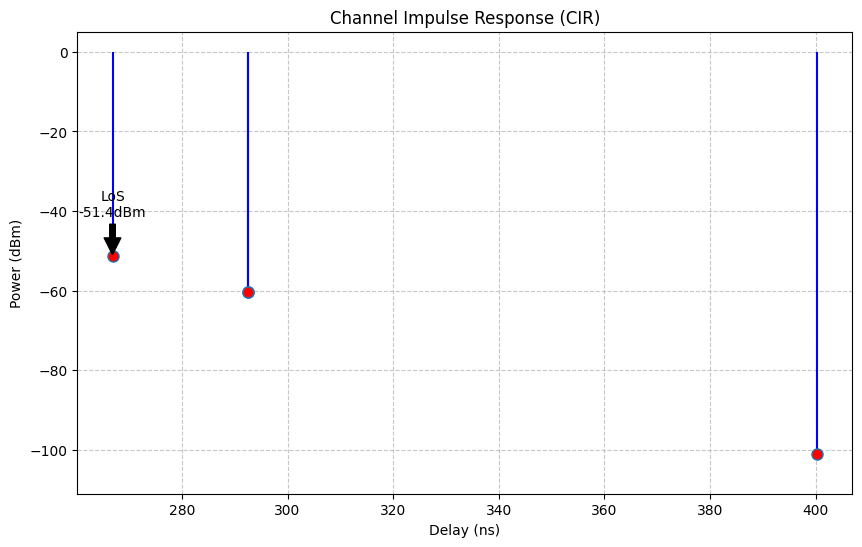

================ 결과 요약 ================
총 경로 수 : 4개
최대 전력  : -51.39 dBm
최소 지연  : 266.85 ns


In [15]:
import matplotlib.pyplot as plt
import numpy as np
import drjit as dr
import mitsuba as mi
import gc
from sionna.rt import PathSolver, Transmitter, Receiver, PlanarArray

# =========================================================
# 1. 환경 초기화 및 메모리 정리 (필수)
# =========================================================
# 기존에 배치된 객체들 제거 (중복 방지)
if hasattr(scene, 'transmitters'):
    for k in list(scene.transmitters.keys()): scene.remove(k)
if hasattr(scene, 'receivers'):
    for k in list(scene.receivers.keys()): scene.remove(k)

# GPU 메모리 정리
dr.flush_kernel_cache()
dr.flush_malloc_cache()
gc.collect()
print("[Info] 초기화 및 메모리 정리 완료")

# =========================================================
# 2. 차량(Tx, Rx) 배치
# =========================================================
# 안테나 패턴 설정
scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")
scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")

# 테스트를 위한 위치 설정 (이전에 사용하신 경로 중 하나 임의 선택)
# 실제로는 road_positions에서 가져온 값을 사용하셔도 됩니다.
# 예: 시작점(Tx)과 약간 떨어진 지점(Rx)
tx_pos = [0, 20, 1.5]     # 예시 좌표 (필요시 수정하세요)
rx_pos = [0, 100, 1.5]    # 예시 좌표

# 송신기(Tx) 배치
tx = Transmitter(name="Tx_Car", position=tx_pos, orientation=[0,0,0])
scene.add(tx)

# 수신기(Rx) 배치
rx = Receiver(name="Rx_Car", position=rx_pos, orientation=[0,0,0])
scene.add(rx)

print(f"[배치] Tx: {tx_pos}, Rx: {rx_pos}")

# =========================================================
# 3. Path Solver 실행 (메모리 안전 설정)
# =========================================================
solver = PathSolver()

print("[Sim] 경로 계산 시작... (잠시만 기다려주세요)")
try:
    # samples_per_src를 1e5(10만)로 줄여서 메모리 오류 방지
    paths = solver(
        scene,
        max_depth=3,               # 최대 반사 횟수
        samples_per_src=int(1e5),  # 광선 수 (메모리 부족 시 1e4로 줄이세요)
        diffraction=False,         # 회절 끄기 (속도 향상)
        diffuse_reflection=False   # 산란 끄기
    )
    print("[Sim] 계산 완료.")
except RuntimeError as e:
    print(f"[Error] 메모리 부족: {e}")
    paths = None

# =========================================================
# 4. 데이터 추출 및 CIR 그래프 그리기
# =========================================================
if paths is not None and paths.a is not None:
    # (1) 데이터 타입 처리 (Tuple vs Tensor)
    # 복소수 이득 (a)
    if isinstance(paths.a, tuple):
        # 튜플로 분리된 경우 (Real, Imag) 합치기
        real_part = paths.a[0].numpy() if hasattr(paths.a[0], 'numpy') else paths.a[0]
        imag_part = paths.a[1].numpy() if hasattr(paths.a[1], 'numpy') else paths.a[1]
        a_val = np.array(real_part) + 1j * np.array(imag_part)
    elif hasattr(paths.a, 'numpy'):
        a_val = paths.a.numpy()
    else:
        a_val = np.array(paths.a)

    # 지연 시간 (tau)
    if isinstance(paths.tau, tuple):
        tau_val = paths.tau[0].numpy() if hasattr(paths.tau[0], 'numpy') else paths.tau[0]
    elif hasattr(paths.tau, 'numpy'):
        tau_val = paths.tau.numpy()
    else:
        tau_val = np.array(paths.tau)

    # 1차원 배열로 변환
    a_np = np.squeeze(a_val)
    tau_np = np.squeeze(tau_val)

    # (2) 유효 데이터 필터링
    # 전력이 0에 가까운 무효 경로 제거
    valid_indices = np.abs(a_np) > 1e-20
    
    if np.sum(valid_indices) > 0:
        path_gains = a_np[valid_indices]
        path_delays = tau_np[valid_indices]

        # dBm 단위 전력 계산
        path_powers_dbm = 10 * np.log10(np.abs(path_gains)**2) + 30
        
        # 시간 단위 변환 (초 -> 나노초 ns)
        path_delays_ns = path_delays * 1e9 

        # (3) 그래프 시각화
        plt.figure(figsize=(10, 6))
        
        markerline, stemlines, baseline = plt.stem(
            path_delays_ns, 
            path_powers_dbm, 
            basefmt=" "
        )
        
        plt.setp(stemlines, 'linewidth', 1.5, 'color', 'b')
        plt.setp(markerline, 'markerfacecolor', 'r', 'markersize', 8)

        # LoS(최대 전력) 표시
        los_idx = np.argmax(path_powers_dbm)
        plt.annotate(
            f'LoS\n{path_powers_dbm[los_idx]:.1f}dBm', 
            xy=(path_delays_ns[los_idx], path_powers_dbm[los_idx]), 
            xytext=(path_delays_ns[los_idx], path_powers_dbm[los_idx] + 10),
            arrowprops=dict(facecolor='black', shrink=0.05),
            ha='center'
        )
        
        # 그래프 범위 및 라벨 설정
        plt.ylim(bottom=max(np.min(path_powers_dbm) - 10, -150))
        plt.title("Channel Impulse Response (CIR)")
        plt.xlabel("Delay (ns)")
        plt.ylabel("Power (dBm)")
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

        print(f"================ 결과 요약 ================")
        print(f"총 경로 수 : {len(path_powers_dbm)}개")
        print(f"최대 전력  : {np.max(path_powers_dbm):.2f} dBm")
        print(f"최소 지연  : {np.min(path_delays_ns):.2f} ns")
        
    else:
        print("[결과] 유효한 경로를 찾지 못했습니다. (차단됨)")
else:
    print("[오류] 시뮬레이션 데이터가 없습니다.")

[설정] 총 거리: 1200.8m, 총 시간: 72.0초
[설정] 측정 스냅샷: 13개

[측정 시작] 메모리 최적화 모드로 진행합니다...
 -> T= 0.0s 모든 설정 실패. 건너뜀.
 -> T= 6.0s 모든 설정 실패. 건너뜀.
 -> T=12.0s 모든 설정 실패. 건너뜀.
 -> T=18.0s 모든 설정 실패. 건너뜀.
 -> T=24.0s 모든 설정 실패. 건너뜀.
 -> T=30.0s 모든 설정 실패. 건너뜀.
 -> T=36.0s 모든 설정 실패. 건너뜀.


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f74ae584ad0>>
Traceback (most recent call last):
  File "/home/lab602/miniconda3/envs/sionna_env/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


 -> T=42.0s 모든 설정 실패. 건너뜀.
 -> T=48.0s 모든 설정 실패. 건너뜀.
 -> T=54.0s 모든 설정 실패. 건너뜀.
 -> T=60.0s 모든 설정 실패. 건너뜀.
 -> T=66.0s 모든 설정 실패. 건너뜀.
 -> T=72.0s 모든 설정 실패. 건너뜀.


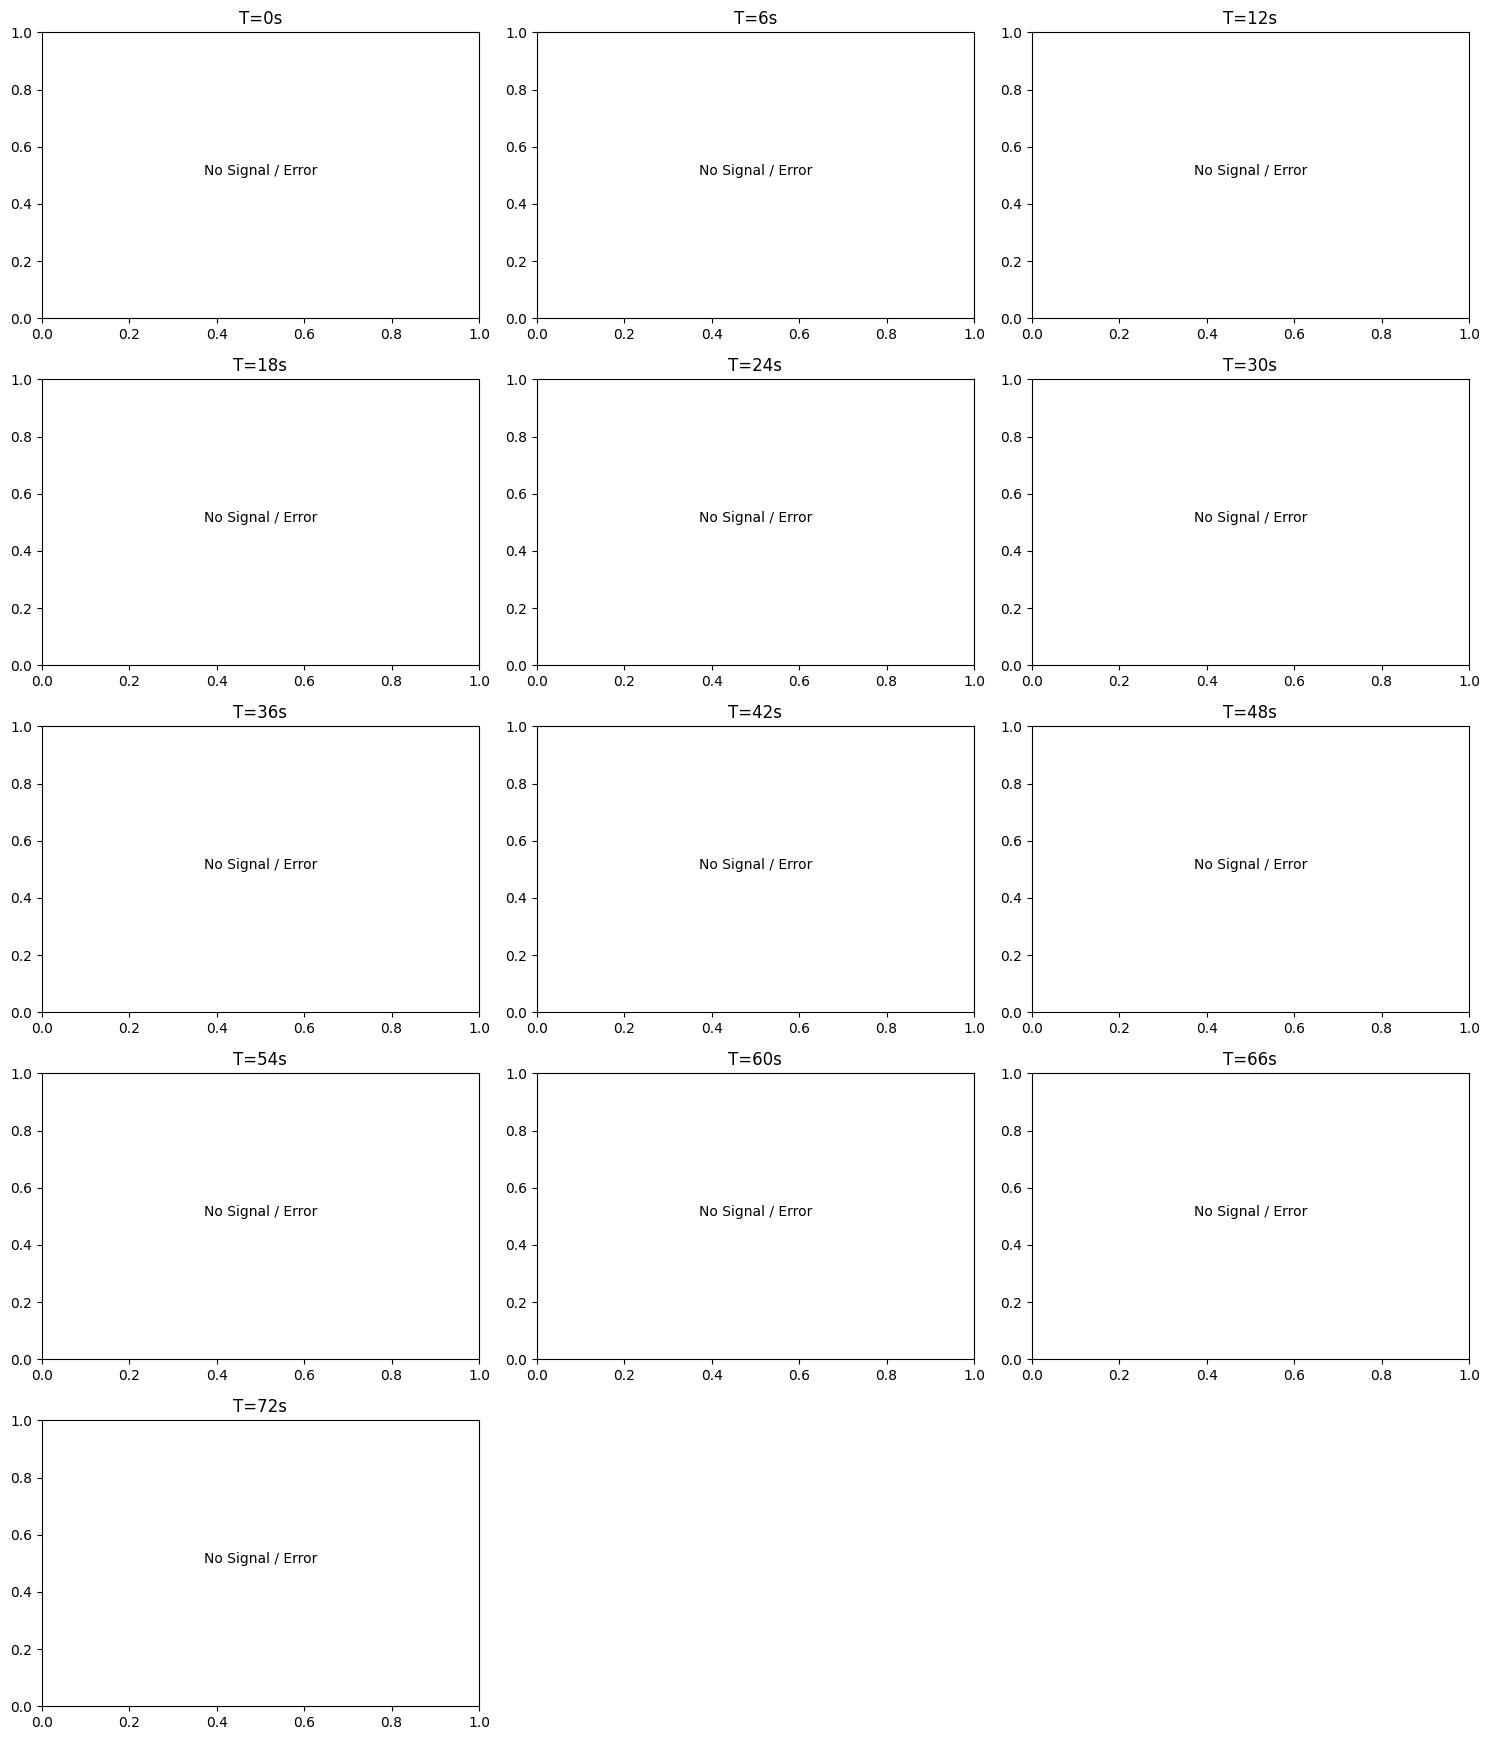

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import drjit as dr
import mitsuba as mi
import gc
import math
from sionna.rt import PathSolver, Transmitter, Receiver, PlanarArray, load_scene

# =========================================================
# 0. 데이터 및 Scene 준비 (안전 장치 포함)
# =========================================================
# Scene 파일 로드
try:
    xml_path = "/data1/mh/sionna/src/sionna/rt/scenes/kookmin/kookmin_itu.xml"
    scene = load_scene(xml_path)
except:
    # 경로가 다를 경우를 대비해 기본 씬 로드 (테스트용)
    from sionna.rt.scene import load_scene
    scene = load_scene(sionna.rt.scene.simple_reflector) 

# road_positions 확인
if 'road_positions' not in globals() or len(road_positions) == 0:
    print("!!! [주의] 'road_positions' 데이터가 없습니다. 임시 경로를 생성합니다. !!!")
    waypoints = np.array([[0,0,1.5], [100,0,1.5]]) # 더미 경로
    cumulative_dists = np.array([0, 100])
    total_distance = 100
    segment_dists = np.array([100])
    speed_ms = 16.6 # 60km/h
    total_time = 6.0
else:
    # 기존 경로 데이터 재사용
    path_indices = [
        412, 410, 408, 406, 404, 401, 400, 72, 69, 68, 342, 340, 338, 335, 334, 
        88, 86, 84, 81, 464, 462, 459, 295, 370, 294, 368, 366, 363, 308, 306, 
        303, 302, 514, 511, 510, 488, 483, 482, 172, 269, 292, 288, 286, 284, 
        281, 604, 601, 507, 289, 506, 268, 522, 517, 516, 122, 120, 117, 116, 
        525, 582
    ]
    max_valid_idx = len(road_positions) - 1
    valid_path = [i for i in path_indices if i <= max_valid_idx]
    waypoints = road_positions[valid_path]
    waypoints[:, 2] += 1.5

    diffs = waypoints[1:] - waypoints[:-1]
    segment_dists = np.linalg.norm(diffs, axis=1)
    cumulative_dists = np.concatenate(([0], np.cumsum(segment_dists)))
    total_distance = cumulative_dists[-1]
    speed_ms = 60.0 * 1000 / 3600 
    total_time = total_distance / speed_ms

def get_location_at_distance(dist):
    dist = np.clip(dist, 0, total_distance)
    idx = np.searchsorted(cumulative_dists, dist) - 1
    idx = max(0, min(idx, len(waypoints) - 2))
    seg_start = cumulative_dists[idx]
    seg_len = segment_dists[idx]
    
    if seg_len == 0: return waypoints[idx], np.zeros(3)
        
    ratio = (dist - seg_start) / seg_len
    pos = waypoints[idx] + ratio * (waypoints[idx+1] - waypoints[idx])
    direction = (waypoints[idx+1] - waypoints[idx]) / seg_len
    velocity = direction * speed_ms
    return pos, velocity

# =========================================================
# 1. 시뮬레이션 환경 설정
# =========================================================
capture_interval = 6.0
capture_times = np.arange(0, total_time, capture_interval)
print(f"[설정] 총 거리: {total_distance:.1f}m, 총 시간: {total_time:.1f}초")
print(f"[설정] 측정 스냅샷: {len(capture_times)}개")

# 객체 초기화
if hasattr(scene, 'transmitters'):
    for k in list(scene.transmitters.keys()): scene.remove(k)
if hasattr(scene, 'receivers'):
    for k in list(scene.receivers.keys()): scene.remove(k)

# 안테나 설정
scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")
scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")

# 기지국 4개 배치
num_bs = 4
bs_indices = np.linspace(0, len(waypoints)-1, num_bs, dtype=int)
for i, idx in enumerate(bs_indices):
    pos = waypoints[idx].copy()
    pos[0] += 30.0; pos[1] += 30.0; pos[2] = 25.0
    scene.add(Transmitter(name=f"BaseStation_{i}", position=pos.tolist()))

# 수신 차량 배치
start_pos, _ = get_location_at_distance(0)
rx = Receiver(name="Car_Rx", position=start_pos.tolist())
scene.add(rx)

solver = PathSolver()
cir_results = []

# =========================================================
# 2. 측정 루프 (자동 품질 조절 기능 탑재)
# =========================================================
print("\n[측정 시작] 메모리 최적화 모드로 진행합니다...")

for t in capture_times:
    current_dist = t * speed_ms
    pos, _ = get_location_at_distance(current_dist)
    rx.position = pos.tolist()
    
    # 메모리 정리 (필수)
    dr.flush_kernel_cache(); dr.flush_malloc_cache(); gc.collect()
    
    paths = None
    used_settings = ""
    
    # -----------------------------------------------------
    # [전략] 1단계: 고품질 시도 -> 실패 시 -> 2단계: 저품질 시도
    # -----------------------------------------------------
    try:
        # [시도 1] 중간 품질 (광선 3만개 + 회절 + 산란)
        # 기존 10만개는 너무 많으므로 3만개로 줄임
        paths = solver(scene, max_depth=3, samples_per_src=int(3e4), 
                       diffraction=True, diffuse_reflection=True)
        used_settings = "Medium (30k rays + Diff + Scat)"
        
    except Exception:
        # 메모리 정리 후 재시도
        dr.flush_kernel_cache(); dr.flush_malloc_cache(); gc.collect()
        try:
            # [시도 2] 저품질 (광선 1만개 + 회절 끄기 + 산란 켜기)
            # 회절(Diffraction)이 메모리를 가장 많이 먹으므로 끕니다.
            paths = solver(scene, max_depth=2, samples_per_src=int(1e4), 
                           diffraction=False, diffuse_reflection=True)
            used_settings = "Low (10k rays + Scat only)"
            
        except Exception as e:
             # [시도 3] 최저 품질 (광선 1만개 + LoS/반사만)
             try:
                paths = solver(scene, max_depth=2, samples_per_src=int(1e4),
                               diffraction=False, diffuse_reflection=False)
                used_settings = "Minimal (10k rays + Specular only)"
             except:
                print(f" -> T={t:4.1f}s 모든 설정 실패. 건너뜀.")
                cir_results.append(None)
                continue

    # -----------------------------------------------------
    # 데이터 처리 (성공한 paths 사용)
    # -----------------------------------------------------
    try:
        snapshot_data = None
        if paths is not None and paths.a is not None:
            # 복소수 변환
            if isinstance(paths.a, tuple):
                a_val = paths.a[0].numpy() + 1j * paths.a[1].numpy()
            elif hasattr(paths.a, 'numpy'):
                a_val = paths.a.numpy()
            else:
                a_val = np.array(paths.a)
                
            if isinstance(paths.tau, tuple):
                tau_val = paths.tau[0].numpy()
            elif hasattr(paths.tau, 'numpy'):
                tau_val = paths.tau.numpy()
            else:
                tau_val = np.array(paths.tau)

            a_np = np.array(a_val); tau_np = np.array(tau_val)
            
            # 차원 정리 (Tx, Paths)
            a_np = np.reshape(a_np, (num_bs, -1))
            tau_np = np.reshape(tau_np, (num_bs, -1))
            
            # Best Server 선정
            bs_powers = np.sum(np.abs(a_np)**2, axis=1)
            best_idx = np.argmax(bs_powers)
            max_pwr = bs_powers[best_idx]
            
            if max_pwr > 1e-25:
                best_a = a_np[best_idx]
                best_tau = tau_np[best_idx]
                valid = np.abs(best_a) > 1e-20
                
                snapshot_data = {
                    "time": t,
                    "dist": current_dist,
                    "best_bs": best_idx,
                    "total_power": 10 * np.log10(max_pwr) + 30,
                    "paths_power": 10 * np.log10(np.abs(best_a[valid])**2) + 30,
                    "paths_delay": best_tau[valid] * 1e9,
                    "settings": used_settings
                }
                print(f" -> T={t:4.1f}s: BS_{best_idx} ({snapshot_data['total_power']:.1f}dBm) | {used_settings}")
            else:
                print(f" -> T={t:4.1f}s: 신호 없음 | {used_settings}")
        
        cir_results.append(snapshot_data)
        
    except Exception as e:
        print(f" -> T={t:4.1f}s 데이터 처리 중 오류: {e}")
        cir_results.append(None)

# =========================================================
# 3. 결과 시각화
# =========================================================
num_plots = len(cir_results)
if num_plots > 0:
    cols = 3
    rows = math.ceil(num_plots / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3.5 * rows))
    axes = axes.flatten()
    
    for i, snap in enumerate(cir_results):
        ax = axes[i]
        if snap is not None:
            markerline, stemlines, baseline = ax.stem(snap["paths_delay"], snap["paths_power"], basefmt=" ")
            plt.setp(stemlines, 'linewidth', 1.0, 'color', 'b')
            plt.setp(markerline, 'markerfacecolor', 'r', 'markersize', 3)
            
            ax.set_title(f"T={snap['time']:.0f}s (BS_{snap['best_bs']})\nPwr:{snap['total_power']:.1f}dBm", fontsize=10)
            ax.set_xlabel("Delay (ns)", fontsize=8)
            ax.set_ylabel("Power (dBm)", fontsize=8)
            ax.grid(True, linestyle=':', alpha=0.6)
            ax.set_ylim(bottom=-150, top=-40)
            
            # 사용된 설정 표시 (작게)
            ax.text(0.95, 0.05, "Optimized", transform=ax.transAxes, 
                    ha='right', fontsize=7, color='gray', alpha=0.7)
        else:
            ax.text(0.5, 0.5, "No Signal / Error", ha='center')
            ax.set_title(f"T={capture_times[i]:.0f}s")
            
    for j in range(i + 1, len(axes)): axes[j].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("결과가 없습니다.")